# 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 2️⃣ Load Dataset

In [2]:
df=pd.read_csv("Digital_Payment_Fraud_Detection_Dataset.csv")
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,T7496,U6242,3962.99,Payment,Card,Web,Delhi,1917,14,0,24820.55,0,0.926,9,0
7496,T7497,U6299,3675.11,Transfer,Card,Web,Hyderabad,329,0,4,6208.20,0,0.036,5,0
7497,T7498,U6605,42523.37,Withdrawal,NetBanking,Android,Chennai,67,19,1,27344.69,0,0.149,6,0
7498,T7499,U5956,10681.86,Withdrawal,UPI,Web,Hyderabad,282,15,2,26586.50,0,0.198,2,0


In [3]:
print(df['transaction_type'].value_counts())
print(df['payment_mode'].value_counts())
print(df['device_type'].value_counts())
print(df['device_location'].value_counts())

transaction_type
Payment       2511
Withdrawal    2499
Transfer      2490
Name: count, dtype: int64
payment_mode
Card          1912
UPI           1874
NetBanking    1862
Wallet        1852
Name: count, dtype: int64
device_type
Web        2537
iOS        2485
Android    2478
Name: count, dtype: int64
device_location
Hyderabad    1614
Bangalore    1518
Chennai      1468
Mumbai       1464
Delhi        1436
Name: count, dtype: int64


In [4]:
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [5]:
df.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 14  fraud_la

# 3️⃣ Data Cleaning

In [7]:
print("Missing Values: \n",df.isnull().sum())

Missing Values: 
 transaction_id              0
user_id                     0
transaction_amount          0
transaction_type            0
payment_mode                0
device_type                 0
device_location             0
account_age_days            0
transaction_hour            0
previous_failed_attempts    0
avg_transaction_amount      0
is_international            0
ip_risk_score               0
login_attempts_last_24h     0
fraud_label                 0
dtype: int64


In [8]:
print("Duplicate Values:\n", df.duplicated().sum())

Duplicate Values:
 0


# 4️⃣ Target Variable Distribution

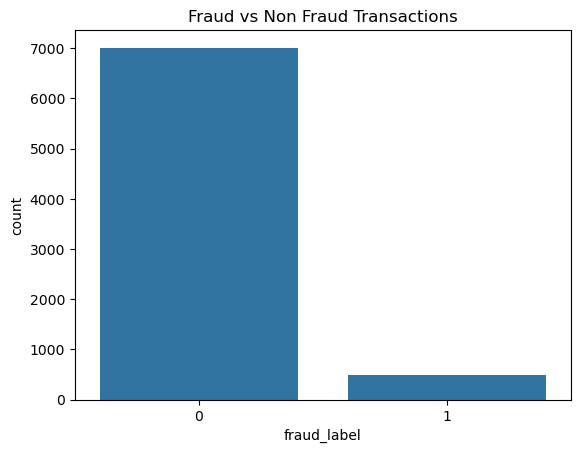

In [9]:
sns.countplot(x="fraud_label",data=df)
plt.title("Fraud vs Non Fraud Transactions")
plt.show()

In [10]:
df['fraud_label'].value_counts()

fraud_label
0    7011
1     489
Name: count, dtype: int64

# 5️⃣ Label Encoding(Categorical Features)

In [11]:
categorical_columns=['transaction_type','payment_mode','device_type','device_location']
le_dict={}
for col in categorical_columns:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    le_dict[col]=le
df  

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,1,2,1,3,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,0,3,2,3,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,0,0,0,1,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,0,3,2,1,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,0,2,1,2,301,4,1,9317.49,1,0.468,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,T7496,U6242,3962.99,0,0,1,2,1917,14,0,24820.55,0,0.926,9,0
7496,T7497,U6299,3675.11,1,0,1,3,329,0,4,6208.20,0,0.036,5,0
7497,T7498,U6605,42523.37,2,1,0,1,67,19,1,27344.69,0,0.149,6,0
7498,T7499,U5956,10681.86,2,2,1,3,282,15,2,26586.50,0,0.198,2,0


In [12]:
print(le_dict['transaction_type'].classes_)
print(le_dict['payment_mode'].classes_)
print(le_dict['device_type'].classes_)
print(le_dict['device_location'].classes_)

['Payment' 'Transfer' 'Withdrawal']
['Card' 'NetBanking' 'UPI' 'Wallet']
['Android' 'Web' 'iOS']
['Bangalore' 'Chennai' 'Delhi' 'Hyderabad' 'Mumbai']


# 6️⃣ Exploratory Data Analysis(EDA)

## Histogram

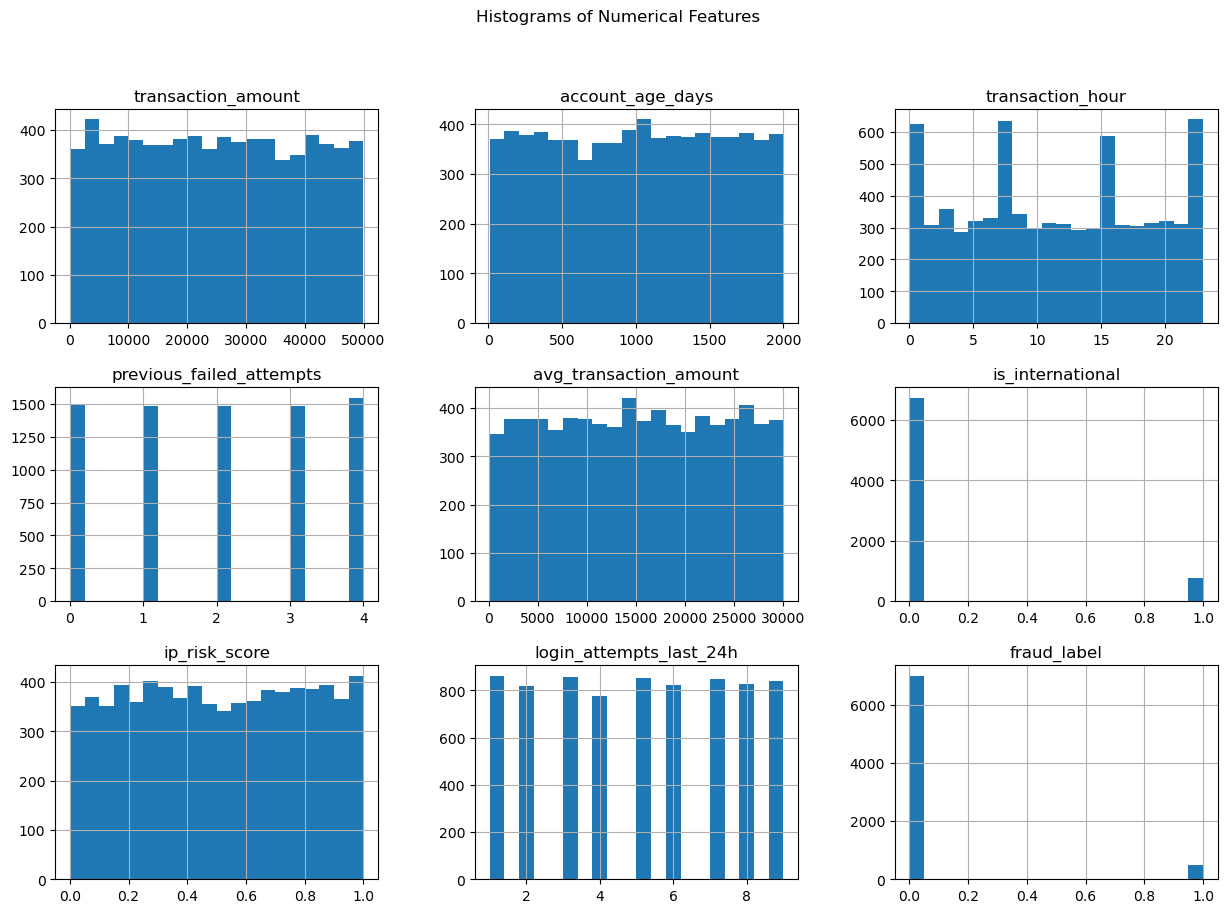

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = [col for col in num_cols if col != 'target'] 
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.show()

##  Boxplot

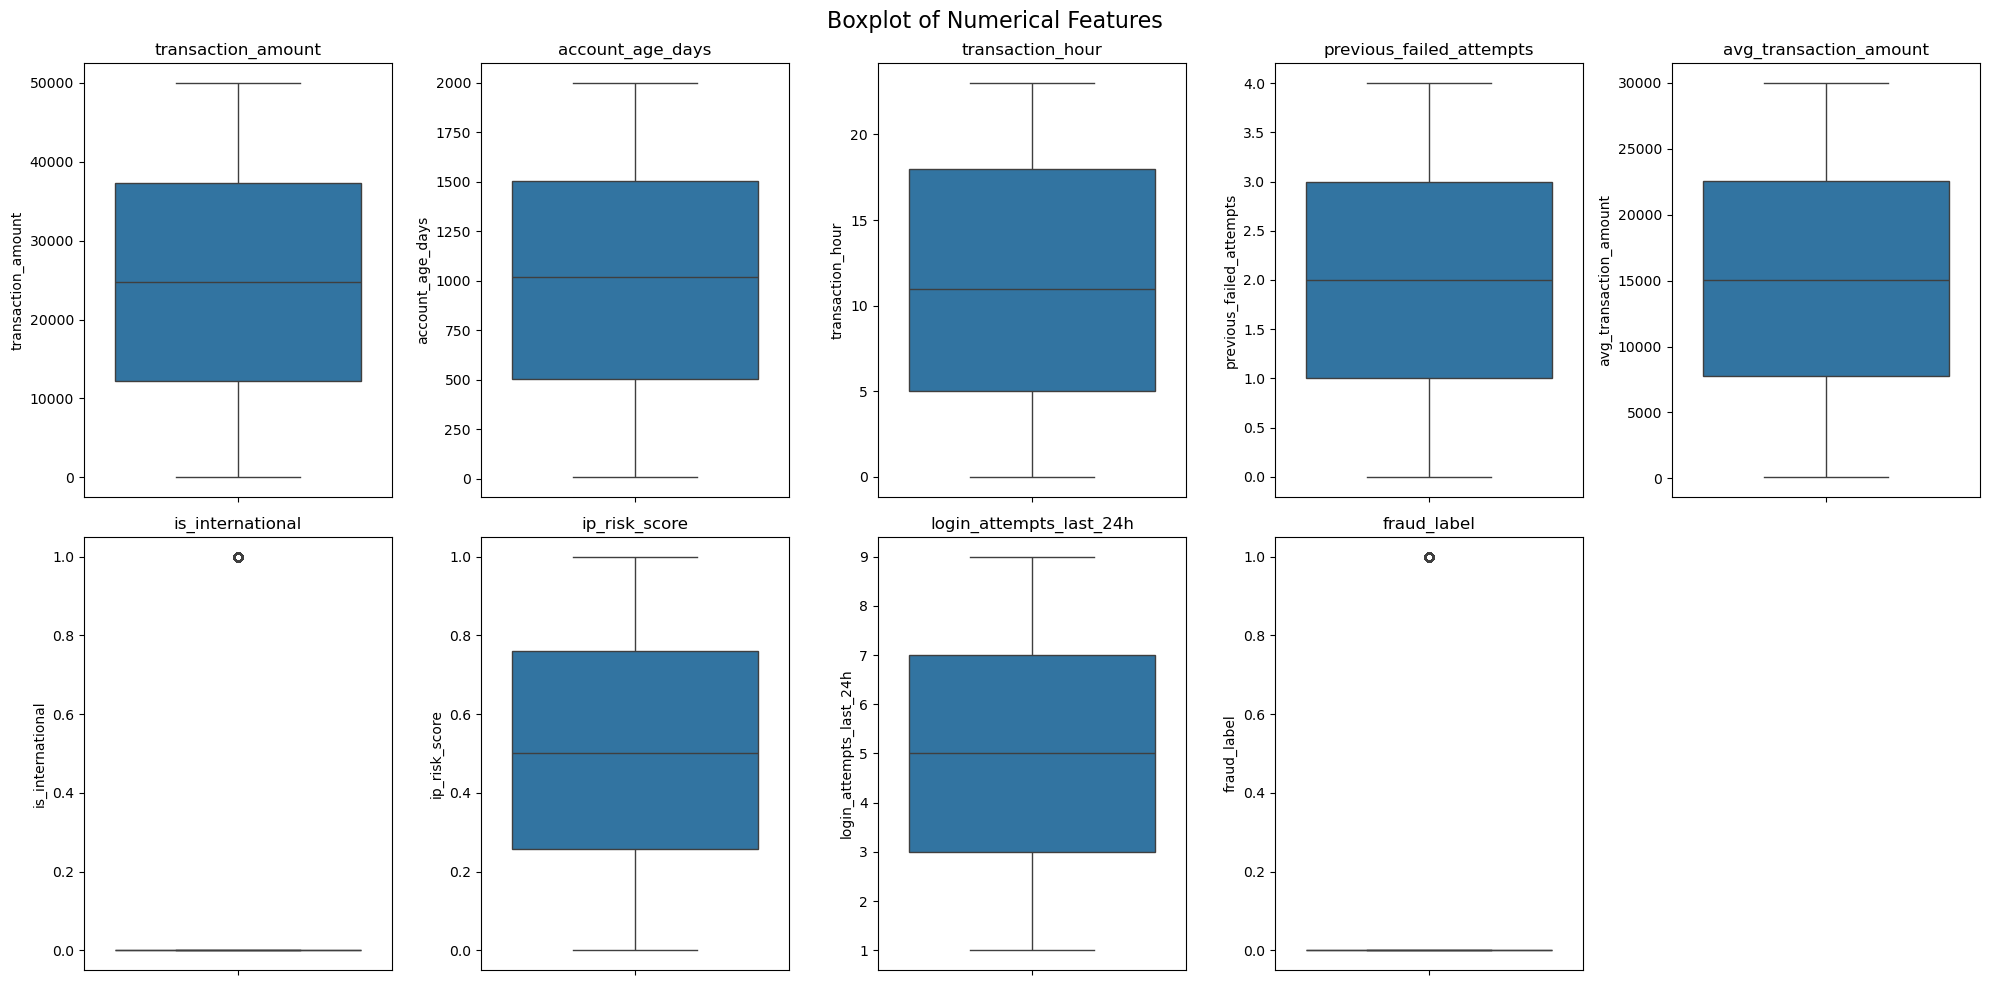

In [14]:
plt.figure(figsize=(20,10))

for idx,col in enumerate(num_cols):
    plt.subplot(2, len(num_cols) // 2 + 1, idx + 1)  
    sns.boxplot(y=df[col])
    plt.title(col)

plt.suptitle("Boxplot of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Fraud vs Transaction Type

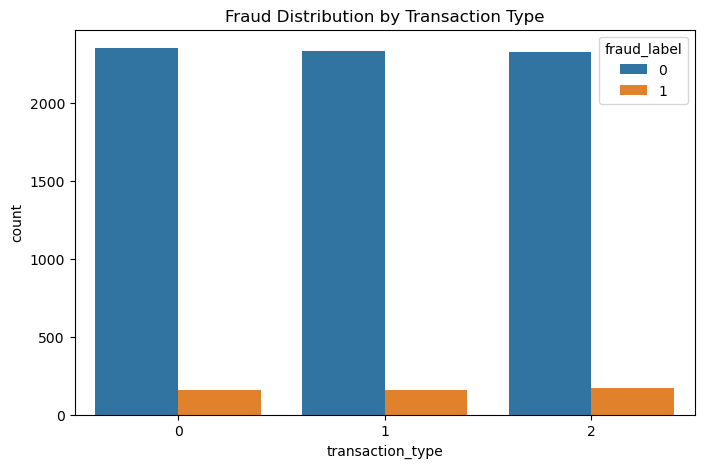

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x="transaction_type", hue="fraud_label",data=df)
plt.title("Fraud Distribution by Transaction Type")
plt.show()

## Correlation Heatmap

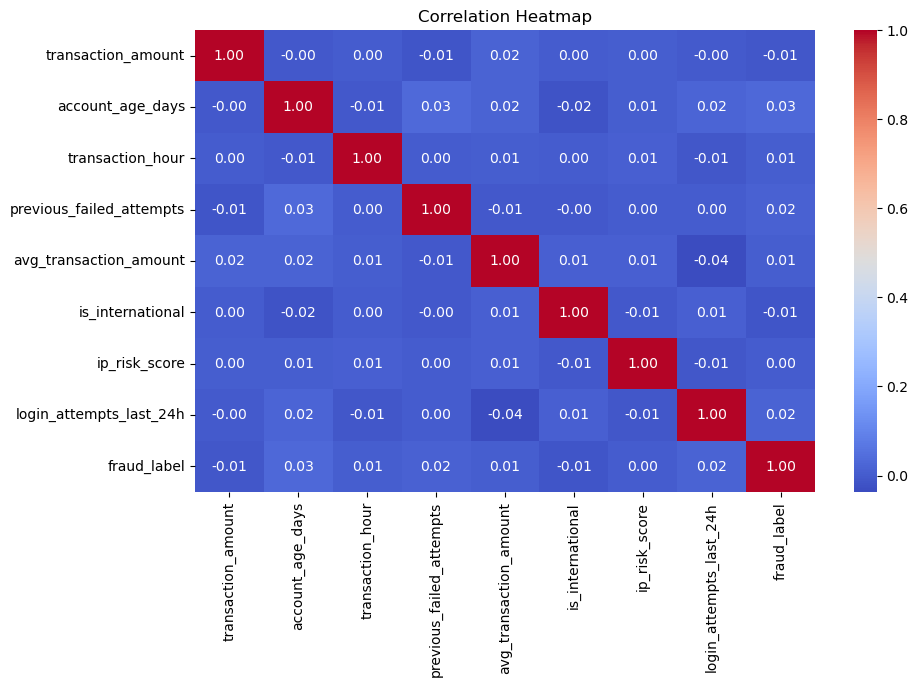

In [16]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm" , fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# 7️⃣  Feature Selection

In [17]:
X=df.drop(['transaction_id','user_id','fraud_label'],axis=1)
X

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h
0,18758.28,1,2,1,3,895,14,1,25535.84,0,0.718,4
1,47538.18,0,3,2,3,918,21,0,3955.85,0,0.525,9
2,36613.10,0,0,0,1,1506,8,4,22727.71,0,0.985,9
3,29952.99,0,3,2,1,800,1,3,18095.89,0,0.797,2
4,7843.13,0,2,1,2,301,4,1,9317.49,1,0.468,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7495,3962.99,0,0,1,2,1917,14,0,24820.55,0,0.926,9
7496,3675.11,1,0,1,3,329,0,4,6208.20,0,0.036,5
7497,42523.37,2,1,0,1,67,19,1,27344.69,0,0.149,6
7498,10681.86,2,2,1,3,282,15,2,26586.50,0,0.198,2


In [18]:
y=df["fraud_label"]
y

0       0
1       0
2       0
3       0
4       0
       ..
7495    0
7496    0
7497    0
7498    0
7499    0
Name: fraud_label, Length: 7500, dtype: int64

# 8️⃣ Train Test Split

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 9️⃣ Feature Scaling 

In [20]:
# Initialize scaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# 🔟 Logistic Regression

In [21]:
lr=LogisticRegression(max_iter=200,class_weight='balanced')
lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [22]:
y_pred_lr=lr.predict(X_test)
y_pred_lr

array([0, 1, 0, ..., 1, 1, 0], dtype=int64)

Logistic Regression Accuracy: 0.5166666666666667
Logistic Regression Confusion Matrix:
 [[726 677]
 [ 48  49]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.52      0.67      1403
           1       0.07      0.51      0.12        97

    accuracy                           0.52      1500
   macro avg       0.50      0.51      0.39      1500
weighted avg       0.88      0.52      0.63      1500



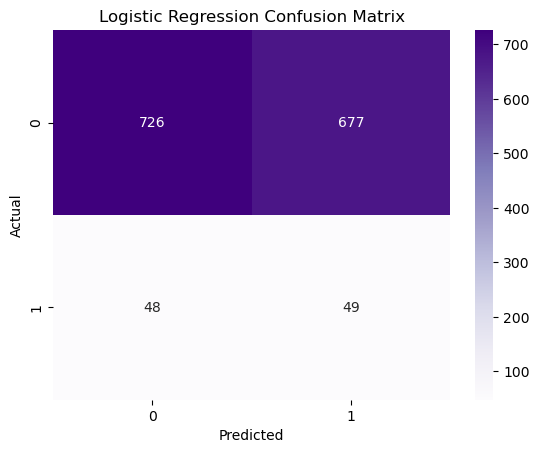

In [23]:
print("Logistic Regression Accuracy:",
accuracy_score(y_test,y_pred_lr))
print("Logistic Regression Confusion Matrix:\n",confusion_matrix(y_test,y_pred_lr))
print("Logistic Regression Classification Report:\n",classification_report(y_test,y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),annot=True,fmt='d',cmap='Purples')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 1️⃣1️⃣ Random Forest 

In [24]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [25]:
y_pred_rf=rf.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

Random Forest Accuracy: 0.9353333333333333
Random Forest Confusion Matrix:
 [[1403    0]
 [  97    0]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1403
           1       0.00      0.00      0.00        97

    accuracy                           0.94      1500
   macro avg       0.47      0.50      0.48      1500
weighted avg       0.87      0.94      0.90      1500



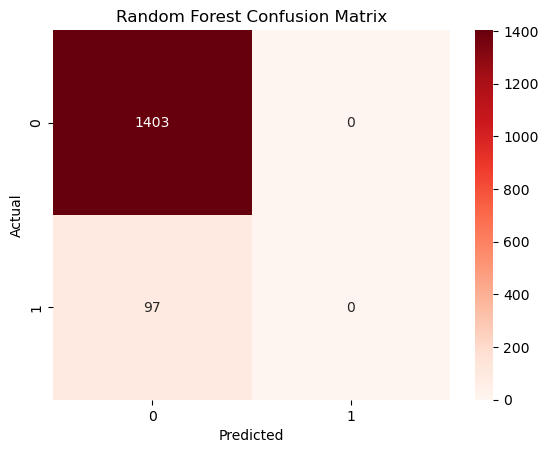

In [26]:
print("Random Forest Accuracy:",
accuracy_score(y_test,y_pred_rf))

print("Random Forest Confusion Matrix:\n",confusion_matrix(y_test,y_pred_rf))
print("Random Forest Classification Report:\n",classification_report(y_test,y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),annot=True,fmt='d',cmap='Reds')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 1️⃣2️⃣ K-Nearest Neighbors

In [27]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [28]:
y_pred_knn=knn.predict(X_test)
y_pred_knn

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

KNN Accuracy: 0.934
KNN Confusion Matrix:
 [[1400    3]
 [  96    1]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1403
           1       0.25      0.01      0.02        97

    accuracy                           0.93      1500
   macro avg       0.59      0.50      0.49      1500
weighted avg       0.89      0.93      0.90      1500



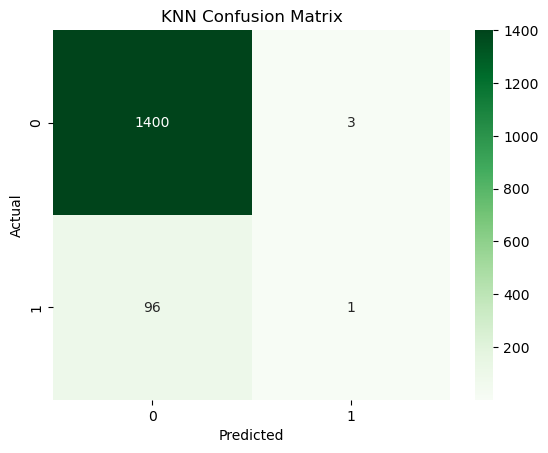

In [29]:
print("KNN Accuracy:",
accuracy_score(y_test,y_pred_knn))

print("KNN Confusion Matrix:\n",confusion_matrix(y_test,y_pred_knn))
print("KNN Classification Report:\n",classification_report(y_test,y_pred_knn))
sns.heatmap(confusion_matrix(y_test, y_pred_knn),annot=True,fmt='d',cmap='Greens')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 1️⃣3️⃣ Support Vector Machine

In [30]:
svm=SVC(class_weight='balanced')
svm.fit(X_train,y_train)

SVC(class_weight='balanced')

In [31]:
y_pred_svm=svm.predict(X_test)
y_pred_svm


array([1, 0, 0, ..., 0, 1, 0], dtype=int64)

SVM Accuracy: 0.6566666666666666
SVM Confusion Matrix:
 [[953 450]
 [ 65  32]]
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.68      0.79      1403
           1       0.07      0.33      0.11        97

    accuracy                           0.66      1500
   macro avg       0.50      0.50      0.45      1500
weighted avg       0.88      0.66      0.74      1500



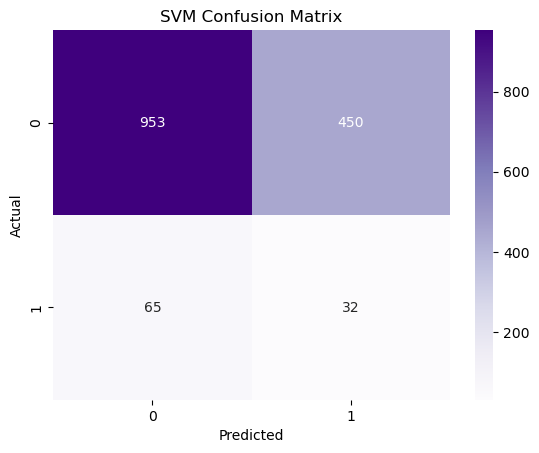

In [32]:
print("SVM Accuracy:",
accuracy_score(y_test,y_pred_svm))

print("SVM Confusion Matrix:\n",confusion_matrix(y_test,y_pred_svm))
print("SVM Classification Report:\n",classification_report(y_test,y_pred_svm))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),annot=True,fmt='d',cmap='Purples')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 1️⃣4️⃣ Gradient Boosting

In [33]:
gb = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [34]:
y_pred_gb = gb.predict(X_test)
y_pred_gb

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

Gradient Boosting Accuracy: 0.934
Gradient Boosting Confusion Matrix:
 [[1401    2]
 [  97    0]]
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1403
           1       0.00      0.00      0.00        97

    accuracy                           0.93      1500
   macro avg       0.47      0.50      0.48      1500
weighted avg       0.87      0.93      0.90      1500



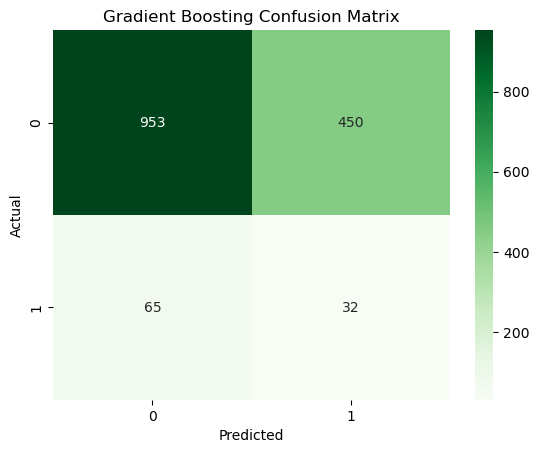

In [35]:
print("Gradient Boosting Accuracy:",
accuracy_score(y_test,y_pred_gb))
print("Gradient Boosting Confusion Matrix:\n",confusion_matrix(y_test,y_pred_gb))
print("Gradient Boosting Classification Report:\n",classification_report(y_test,y_pred_gb))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),annot=True,fmt='d',cmap='Greens')
plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 1️⃣5️⃣ Hyperparameter Tuning(Random Forest)

In [36]:
param_dist = {

'n_estimators':[100,200,300],
'max_depth':[10,20,30,None],
'min_samples_split':[2,5,10],
'min_samples_leaf':[1,2,4],
'bootstrap':[True,False]
}

random_search = RandomizedSearchCV(
estimator=rf,
param_distributions=param_dist,
n_iter=20,
cv=5,
random_state=42,
n_jobs=-1
)

random_search.fit(X_train,y_train)

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Optimized Random Forest Accuracy:",accuracy_score(y_test,y_pred_best))

Optimized Random Forest Accuracy: 0.9346666666666666


# 1️⃣6️⃣ Feature Importance

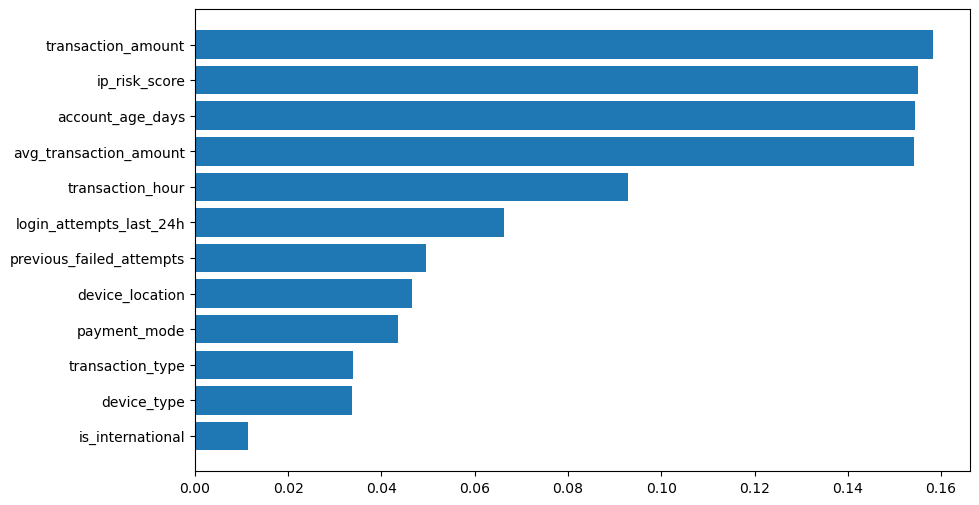

In [37]:
importances = rf.feature_importances_
features = X.columns

indices=np.argsort(importances)
plt.figure(figsize=(10,6))
# plt.title("Feature Importance")
# sns.barplot(x=importances,y=features)
# plt.show()
plt.barh(range(len(indices)),importances[indices])
plt.yticks(range(len(indices)),[features[i] for i in indices])
plt.show()

# 1️⃣7️⃣ Model Comparison Graph

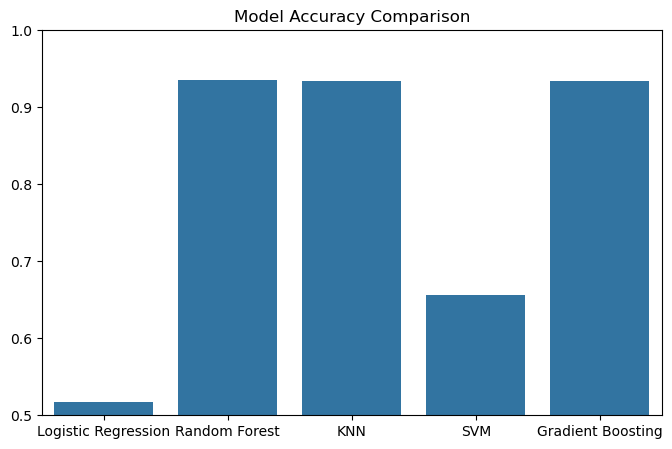

In [38]:
models = ["Logistic Regression","Random Forest","KNN","SVM","Gradient Boosting"]

scores = [accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_rf),
accuracy_score(y_test,y_pred_knn),accuracy_score(y_test,y_pred_svm),accuracy_score(y_test,y_pred_gb)]

plt.figure(figsize=(8,5))
sns.barplot(x=models,y=scores)

plt.title("Model Accuracy Comparison")

plt.ylim(0.5,1)

plt.show()

# 1️⃣8️⃣ Save a Model

In [39]:
import pickle
with open('Fraud_Detection.pkl', 'wb') as file:
    pickle.dump(rf , file)

print("Model saved successfully!")

Model saved successfully!


In [40]:
import os

# Check if the file exists and print its absolute path
model_path = 'Fraud_Detection.pkl'
if os.path.exists(model_path):
    print("Model saved at:", os.path.abspath(model_path))  # prints the absolute path
else:
    print("Model not found!")


Model saved at: C:\Desktop\Machine Learning Libraries\proj\ML\Fraud_Detection.pkl


In [41]:
import os

# Check the size of the model file
model_size = os.path.getsize('Fraud_Detection.pkl')  # replace with your model's path
print(f"Model size: {model_size / 1024:.2f} KB")  # Convert bytes to KB

Model size: 15653.78 KB


# 1️⃣9️⃣ New Transaction Prediction

In [42]:
new_transaction={'transaction_amount':15246.9,'transaction_type':0,
'payment_mode':2,'device_type':1,'device_location':3,
'account_age_days':1978,'transaction_hour':4,
'previous_failed_attempts':1,'avg_transaction_amount':28448.77,
'is_international':0,'ip_risk_score':0.58,'login_attempts_last_24h':2}

new_df = pd.DataFrame([new_transaction])
new_df = new_df[X.columns]
# Apply scaling
new_df = scaler.transform(new_df)
prediction = rf.predict(new_df)

print("Prediction (0=Not Fraud,1=Fraud):",prediction[0])
                 

Prediction (0=Not Fraud,1=Fraud): 0


In [43]:
new_transaction={'transaction_amount':11683.45,'transaction_type':1,'payment_mode':1,'device_type':1,'device_location':1,'account_age_days':1843,'transaction_hour':10,'previous_failed_attempts':3,'avg_transaction_amount':6090.84,'is_international':0,'ip_risk_score':0.002,'login_attempts_last_24h':8}
new_df=pd.DataFrame([new_transaction])
new_df = new_df[X.columns]
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])
                 

Prediction(0=Not Fraud,1=Fraud): 1


In [44]:
new_transaction={'transaction_amount':90000,'transaction_type':2,'payment_mode':3,'device_type':2,'device_location':4,'account_age_days':2,'transaction_hour':2,'previous_failed_attempts':12,'avg_transaction_amount':500,'is_international':1,'ip_risk_score':0.95,'login_attempts_last_24h':20}
new_df=pd.DataFrame([new_transaction])
new_df = new_df[X.columns]
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])

Prediction(0=Not Fraud,1=Fraud): 1


In [45]:
new_transaction={'transaction_amount':1200,'transaction_type':1,'payment_mode':1,'device_type':0,'device_location':1,'account_age_days':1500,'transaction_hour':14,'previous_failed_attempts':0,'avg_transaction_amount':1100,'is_international':0,'ip_risk_score':0,'login_attempts_last_24h':1}
new_df=pd.DataFrame([new_transaction])
new_df = new_df[X.columns]
new_df=scaler.transform(new_df)
prediction=rf.predict(new_df)
print("Prediction(0=Not Fraud,1=Fraud):",prediction[0])

Prediction(0=Not Fraud,1=Fraud): 0


In [46]:
import pickle

pickle.dump(rf, open("Fraud_Detection.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

print("Model and scaler saved!")

Model and scaler saved!


In [49]:
!pip install gradio

   ---------------------------------------- 0.0/32.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/32.3 MB ? eta -:--:--
    --------------------------------------- 0.8/32.3 MB 1.9 MB/s eta 0:00:17
   - -------------------------------------- 1.0/32.3 MB 1.9 MB/s eta 0:00:17
   - -------------------------------------- 1.6/32.3 MB 2.0 MB/s eta 0:00:16
   -- ------------------------------------- 1.8/32.3 MB 2.1 MB/s eta 0:00:15
   --- ------------------------------------ 2.6/32.3 MB 2.1 MB/s eta 0:00:14
   ---- ----------------------------------- 3.4/32.3 MB 2.3 MB/s eta 0:00:13
   ---- ----------------------------------- 3.9/32.3 MB 2.5 MB/s eta 0:00:12
   ----- ---------------------------------- 4.2/32.3 MB 2.4 MB/s eta 0:00:12
   ------ --------------------------------- 5.2/32.3 MB 2.5 MB/s eta 0:00:11
   ------- -------------------------------- 6.0/32.3 MB 2.7 MB/s eta 0:00:10
   -------- ------------------------------- 6.8/32.3 MB 2.7 MB/s eta 0:00:10
   ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [50]:
import gradio as gr
import pickle
import numpy as np

# Load model and scaler
model = pickle.load(open("Fraud_Detection.pkl","rb"))
scaler = pickle.load(open("scaler.pkl","rb"))

# Prediction function
def predict_fraud(
    transaction_amount,
    transaction_type,
    payment_mode,
    device_type,
    device_location,
    account_age_days,
    transaction_hour,
    previous_failed_attempts,
    avg_transaction_amount,
    is_international,
    ip_risk_score,
    login_attempts_last_24h
):

    data = np.array([[transaction_amount,
                      transaction_type,
                      payment_mode,
                      device_type,
                      device_location,
                      account_age_days,
                      transaction_hour,
                      previous_failed_attempts,
                      avg_transaction_amount,
                      is_international,
                      ip_risk_score,
                      login_attempts_last_24h]])

    data = scaler.transform(data)

    prob = model.predict_proba(data)[0][1]

    if prob > 0.30:
        result = f"🚨 Fraud Transaction Detected\nRisk Score: {prob:.2f}"
    else:
        result = f"✅ Legitimate Transaction\nRisk Score: {prob:.2f}"

    return result, prob


# Custom CSS for better design
css = """
body {
    background: linear-gradient(135deg,#0f2027,#203a43,#2c5364);
}
#title {
    text-align:center;
    font-size:32px;
    font-weight:bold;
    color:white;
}
#card {
    background:white;
    padding:20px;
    border-radius:15px;
}
"""

# UI
with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 💳 Digital Payment Fraud Detection", elem_id="title")

    with gr.Group(elem_id="card"):

        gr.Markdown(
        "Enter the transaction details to detect whether the payment is **Fraudulent or Legitimate**."
        )

        with gr.Row():

            with gr.Column():

                transaction_amount = gr.Number(label="Transaction Amount")

                transaction_type = gr.Dropdown(
                    choices=[
                        ("Payment",0),
                        ("Transfer",1),
                        ("Withdrawal",2)
                    ],
                    label="Transaction Type",
                    value=0
                )

                payment_mode = gr.Dropdown(
                    choices=[
                        ("Card",0),
                        ("Net Banking",1),
                        ("UPI",2),
                        ("Wallet",3)
                    ],
                    label="Payment Mode",
                    value=0
                )

                device_type = gr.Dropdown(
                    choices=[
                        ("Android",0),
                        ("iOS",1),
                        ("Web",2)
                    ],
                    label="Device Type",
                    value=0
                )

                device_location = gr.Dropdown(
                    choices=[
                        ("Bangalore",0),
                        ("Chennai",1),
                        ("Delhi",2),
                        ("Hyderabad",3),
                        ("Mumbai",4)
                    ],
                    label="Device Location",
                    value=0
                )

                is_international = gr.Dropdown(
                    choices=[
                        ("No",0),
                        ("Yes",1)
                    ],
                    label="International Transaction",
                    value=0
                )

            with gr.Column():

                account_age_days = gr.Number(label="Account Age (Days)")

                transaction_hour = gr.Slider(
                    0,23,step=1,label="Transaction Hour"
                )

                previous_failed_attempts = gr.Slider(
                    0,20,step=1,label="Previous Failed Attempts"
                )

                avg_transaction_amount = gr.Number(
                    label="Average Transaction Amount"
                )

                ip_risk_score = gr.Slider(
                    0,1,step=0.01,label="IP Risk Score"
                )

                login_attempts_last_24h = gr.Slider(
                    0,20,step=1,label="Login Attempts Last 24 Hours"
                )

        predict_btn = gr.Button("🔍 Analyze Transaction", variant="primary")

        result = gr.Textbox(label="Prediction Result")

        probability = gr.Slider(
            0,1,
            label="Fraud Probability",
            interactive=False
        )

        predict_btn.click(
            predict_fraud,
            inputs=[
                transaction_amount,
                transaction_type,
                payment_mode,
                device_type,
                device_location,
                account_age_days,
                transaction_hour,
                previous_failed_attempts,
                avg_transaction_amount,
                is_international,
                ip_risk_score,
                login_attempts_last_24h
            ],
            outputs=[result, probability]
        )

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
